In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/vikasa s y/Downloads/web-scraping-quotes-analysis/data/raw/quotes_raw.csv")

In [3]:
df.shape

(100, 3)

In [4]:
df.head(10)

,quote,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"['change', 'deep-thoughts', 'thinking', 'world']"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"['abilities', 'choices']"
2,“There are only two ways to live your life. On...,Albert Einstein,"['inspirational', 'life', 'live', 'miracle', '..."
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"['aliteracy', 'books', 'classic', 'humor']"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"['be-yourself', 'inspirational']"
5,“Try not to become a man of success. Rather be...,Albert Einstein,"['adulthood', 'success', 'value']"
6,“It is better to be hated for what you are tha...,André Gide,"['life', 'love']"
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"['edison', 'failure', 'inspirational', 'paraph..."
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,['misattributed-eleanor-roosevelt']
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"['humor', 'obvious', 'simile']"


In [5]:
df.describe()

,quote,author,tags
count,100,100,100
unique,100,50,84
top,“The world as we have created it is a process ...,Albert Einstein,['love']
freq,1,10,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   quote   100 non-null    object
 1   author  100 non-null    object
 2   tags    100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [7]:
df.isnull().sum()

quote     0
author    0
tags      0
dtype: int64

In [8]:
df.tail(10)

,quote,author,tags
90,"“The truth."" Dumbledore sighed. ""It is a beaut...",J.K. Rowling,['truth']
91,“I'm the one that's got to die when it's time ...,Jimi Hendrix,"['death', 'life']"
92,“To die will be an awfully big adventure.”,J.M. Barrie,"['adventure', 'love']"
93,“It takes courage to grow up and become who yo...,E.E. Cummings,['courage']
94,“But better to get hurt by the truth than comf...,Khaled Hosseini,['life']
95,“You never really understand a person until yo...,Harper Lee,['better-life-empathy']
96,“You have to write the book that wants to be w...,Madeleine L'Engle,"['books', 'children', 'difficult', 'grown-ups'..."
97,“Never tell the truth to people who are not wo...,Mark Twain,['truth']
98,"“A person's a person, no matter how small.”",Dr. Seuss,['inspirational']
99,“... a mind needs books as a sword needs a whe...,George R.R. Martin,"['books', 'mind']"


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

quote     object
author    object
tags      object
dtype: object

## 🔍 Initial Data Investigation

Before performing any cleaning, the raw dataset was inspected to understand its structure, data types, missing values, duplicates, and potential data-quality issues.

### Investigation Results

* **Columns:** `quote`, `author`, `tags`
* **Number of records:** 100
* **Data types:** All three columns are currently stored as `object`
* **Missing values:** No missing values were found
* **Duplicate rows:** No duplicate rows were found
* **Initial data-quality check:** No obvious inconsistencies or suspicious values were identified during the initial inspection.

### Next Step

The individual columns will be investigated in more detail before making any cleaning decisions, particularly the `tags` column because it contains lists of tags rather than simple text values.


In [11]:
print(df['quote'].dtypes)
print(df['author'].dtypes)
print(df['tags'].dtypes)

object
object
object


In [12]:
print(df['quote'].iloc[0])
print(df['author'].iloc[0])
print(df['tags'].iloc[0])

“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Albert Einstein
['change', 'deep-thoughts', 'thinking', 'world']


In [13]:
(df['tags'].apply(len))

0     48
1     24
2     56
3     42
4     32
      ..
95    23
96    78
97     9
98    17
99    17
Name: tags, Length: 100, dtype: int64

In [14]:
import ast
ast.literal_eval(df['tags'].iloc[0])

['change', 'deep-thoughts', 'thinking', 'world']

In [15]:
type(ast.literal_eval(df['tags'].iloc[0]))

list

In [16]:
df['tags'] = (df['tags'].apply(ast.literal_eval))

In [17]:
df['tags']


0              [change, deep-thoughts, thinking, world]
1                                  [abilities, choices]
2        [inspirational, life, live, miracle, miracles]
3                    [aliteracy, books, classic, humor]
4                          [be-yourself, inspirational]
                            ...                        
95                                [better-life-empathy]
96    [books, children, difficult, grown-ups, write,...
97                                              [truth]
98                                      [inspirational]
99                                        [books, mind]
Name: tags, Length: 100, dtype: object

In [18]:
tags_count = (df['tags'].apply(len))

In [19]:
print(tags_count.max())

8


In [20]:
print(tags_count.min())

0


In [21]:
df.loc[tags_count == 0]

,quote,author,tags
27,“It is impossible to live without failing at s...,J.K. Rowling,[]
42,“You believe lies so you eventually learn to t...,Marilyn Monroe,[]
78,“The question isn't who is going to let me; it...,Ayn Rand,[]


### Tags Investigation

The `tags` column initially appeared as a string after loading the CSV because CSV does not preserve Python list objects. The values were converted back into lists using `ast.literal_eval()`.

Further investigation showed:

* The `tags` column contains lists after conversion.
* Most quotes have one or more tags.
* 3 quotes have an empty tag list (`[]`).
* These occur at indices 27, 42, and 78.
* Empty tag lists are treated as valid values because they indicate that no tags were assigned to those quotes rather than missing or corrupted records.
* Therefore, these rows will **not be removed** during cleaning.


## Quotes Investigation

In [22]:
df['quote'].duplicated().sum()

np.int64(0)

In [23]:
string_count = (df['quote'].apply(len))

In [24]:
df['quote'].isnull() == True

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: quote, Length: 100, dtype: bool

In [25]:
string_count

0     115
1      85
2     131
3     104
4     111
     ... 
95    148
96    139
97     58
98     43
99     81
Name: quote, Length: 100, dtype: int64

In [26]:
df['quote'] = df['quote'].str.strip()

In [27]:
df['quote']

0     “The world as we have created it is a process ...
1     “It is our choices, Harry, that show what we t...
2     “There are only two ways to live your life. On...
3     “The person, be it gentleman or lady, who has ...
4     “Imperfection is beauty, madness is genius and...
                            ...                        
95    “You never really understand a person until yo...
96    “You have to write the book that wants to be w...
97    “Never tell the truth to people who are not wo...
98          “A person's a person, no matter how small.”
99    “... a mind needs books as a sword needs a whe...
Name: quote, Length: 100, dtype: object

## Author Investigate

In [28]:
df['author'].isnull().sum()

np.int64(0)

In [29]:
print(df['author'].duplicated().sum())

50


In [30]:
df['author'].nunique()

50

In [31]:
df['author'].value_counts()

author
Albert Einstein           10
J.K. Rowling               9
Marilyn Monroe             7
Dr. Seuss                  6
Mark Twain                 6
Jane Austen                5
C.S. Lewis                 5
Bob Marley                 3
Mother Teresa              2
Eleanor Roosevelt          2
Charles Bukowski           2
Ernest Hemingway           2
George R.R. Martin         2
Suzanne Collins            2
Ralph Waldo Emerson        2
Steve Martin               1
André Gide                 1
Thomas A. Edison           1
Allen Saunders             1
Pablo Neruda               1
Elie Wiesel                1
Friedrich Nietzsche        1
Douglas Adams              1
Charles M. Schulz          1
William Nicholson          1
Garrison Keillor           1
Jorge Luis Borges          1
Martin Luther King Jr.     1
Haruki Murakami            1
James Baldwin              1
Alexandre Dumas fils       1
Stephenie Meyer            1
George Eliot               1
Jim Henson                 1
George 

In [32]:
df['author'].dtypes

dtype('O')

In [33]:
df['author'].str.strip()

0        Albert Einstein
1           J.K. Rowling
2        Albert Einstein
3            Jane Austen
4         Marilyn Monroe
             ...        
95            Harper Lee
96     Madeleine L'Engle
97            Mark Twain
98             Dr. Seuss
99    George R.R. Martin
Name: author, Length: 100, dtype: object

In [34]:
(df['author'] != df['author'].str.strip()).sum()

np.int64(0)

In [35]:
df['author'].unique()

array(['Albert Einstein', 'J.K. Rowling', 'Jane Austen', 'Marilyn Monroe',
       'André Gide', 'Thomas A. Edison', 'Eleanor Roosevelt',
       'Steve Martin', 'Bob Marley', 'Dr. Seuss', 'Douglas Adams',
       'Elie Wiesel', 'Friedrich Nietzsche', 'Mark Twain',
       'Allen Saunders', 'Pablo Neruda', 'Ralph Waldo Emerson',
       'Mother Teresa', 'Garrison Keillor', 'Jim Henson',
       'Charles M. Schulz', 'William Nicholson', 'Jorge Luis Borges',
       'George Eliot', 'George R.R. Martin', 'C.S. Lewis',
       'Martin Luther King Jr.', 'James Baldwin', 'Haruki Murakami',
       'Alexandre Dumas fils', 'Stephenie Meyer', 'Ernest Hemingway',
       'Helen Keller', 'George Bernard Shaw', 'Charles Bukowski',
       'Suzanne Collins', 'J.R.R. Tolkien', 'Alfred Tennyson',
       'Terry Pratchett', 'J.D. Salinger', 'George Carlin', 'John Lennon',
       'W.C. Fields', 'Ayn Rand', 'Jimi Hendrix', 'J.M. Barrie',
       'E.E. Cummings', 'Khaled Hosseini', 'Harper Lee',
       "Madeleine L'E

## Tag Investigation

In [36]:
df['tags'].explode()

0            change
0     deep-thoughts
0          thinking
0             world
1         abilities
          ...      
96          writing
97            truth
98    inspirational
99            books
99             mind
Name: tags, Length: 235, dtype: object

In [37]:
df['tags'].explode().value_counts()

tags
love             14
inspirational    13
life             13
humor            12
books            11
                 ..
difficult         1
grown-ups         1
write             1
writers           1
mind              1
Name: count, Length: 137, dtype: int64

In [38]:
[ tag.strip() for tags_list in df['tags'] for tag in tags_list ]

['change',
 'deep-thoughts',
 'thinking',
 'world',
 'abilities',
 'choices',
 'inspirational',
 'life',
 'live',
 'miracle',
 'miracles',
 'aliteracy',
 'books',
 'classic',
 'humor',
 'be-yourself',
 'inspirational',
 'adulthood',
 'success',
 'value',
 'life',
 'love',
 'edison',
 'failure',
 'inspirational',
 'paraphrased',
 'misattributed-eleanor-roosevelt',
 'humor',
 'obvious',
 'simile',
 'friends',
 'heartbreak',
 'inspirational',
 'life',
 'love',
 'sisters',
 'courage',
 'friends',
 'simplicity',
 'understand',
 'love',
 'fantasy',
 'life',
 'navigation',
 'activism',
 'apathy',
 'hate',
 'indifference',
 'inspirational',
 'love',
 'opposite',
 'philosophy',
 'friendship',
 'lack-of-friendship',
 'lack-of-love',
 'love',
 'marriage',
 'unhappy-marriage',
 'books',
 'contentment',
 'friends',
 'friendship',
 'life',
 'fate',
 'life',
 'misattributed-john-lennon',
 'planning',
 'plans',
 'love',
 'poetry',
 'happiness',
 'attributed-no-source',
 'humor',
 'religion',
 'humor',

In [39]:
sum(
    tag != tag.strip()
    for tags in df['tags']
    for tag in tags
)

0

In [40]:
tags = df['tags'].iloc[0]

In [41]:
len(tags)

4

In [42]:
len(set(tags))

4

In [43]:
[ (len(tags) , len(set(tags))) for tags in df['tags'] ]

[(4, 4),
 (2, 2),
 (5, 5),
 (4, 4),
 (2, 2),
 (3, 3),
 (2, 2),
 (4, 4),
 (1, 1),
 (3, 3),
 (6, 6),
 (2, 2),
 (2, 2),
 (1, 1),
 (1, 1),
 (2, 2),
 (8, 8),
 (6, 6),
 (5, 5),
 (5, 5),
 (2, 2),
 (1, 1),
 (1, 1),
 (2, 2),
 (1, 1),
 (3, 3),
 (2, 2),
 (0, 0),
 (1, 1),
 (1, 1),
 (3, 3),
 (1, 1),
 (1, 1),
 (2, 2),
 (2, 2),
 (3, 3),
 (2, 2),
 (4, 4),
 (2, 2),
 (1, 1),
 (4, 4),
 (4, 4),
 (0, 0),
 (2, 2),
 (2, 2),
 (1, 1),
 (1, 1),
 (2, 2),
 (1, 1),
 (1, 1),
 (2, 2),
 (3, 3),
 (1, 1),
 (1, 1),
 (2, 2),
 (1, 1),
 (3, 3),
 (3, 3),
 (1, 1),
 (3, 3),
 (1, 1),
 (1, 1),
 (1, 1),
 (1, 1),
 (6, 6),
 (1, 1),
 (2, 2),
 (2, 2),
 (1, 1),
 (1, 1),
 (2, 2),
 (1, 1),
 (3, 3),
 (2, 2),
 (5, 5),
 (6, 6),
 (8, 8),
 (2, 2),
 (0, 0),
 (3, 3),
 (1, 1),
 (4, 4),
 (1, 1),
 (3, 3),
 (2, 2),
 (3, 3),
 (1, 1),
 (2, 2),
 (2, 2),
 (4, 4),
 (1, 1),
 (2, 2),
 (2, 2),
 (1, 1),
 (1, 1),
 (1, 1),
 (7, 7),
 (1, 1),
 (1, 1),
 (2, 2)]

## 🔍 Column Investigation Summary

* **Quote:** No missing or duplicate quotes were found. Leading/trailing whitespace was removed.
* **Author:** 50 unique authors were identified. No missing values, extra whitespace, or obvious formatting inconsistencies were found.
* **Tags:** The column contains valid lists with 235 total tag entries and 137 unique tags. Three quotes have empty tag lists, which were treated as valid values. No whitespace or duplicate tags were found within individual quotes.

### Conclusion

The dataset contains no major data-quality issues requiring extensive cleaning. Only minor preprocessing was needed, while valid values were preserved.


In [44]:
df.head(10)

,quote,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"[change, deep-thoughts, thinking, world]"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"[abilities, choices]"
2,“There are only two ways to live your life. On...,Albert Einstein,"[inspirational, life, live, miracle, miracles]"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"[aliteracy, books, classic, humor]"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"[be-yourself, inspirational]"
5,“Try not to become a man of success. Rather be...,Albert Einstein,"[adulthood, success, value]"
6,“It is better to be hated for what you are tha...,André Gide,"[life, love]"
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"[edison, failure, inspirational, paraphrased]"
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,[misattributed-eleanor-roosevelt]
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"[humor, obvious, simile]"


In [45]:
df.tail(10)

,quote,author,tags
90,"“The truth."" Dumbledore sighed. ""It is a beaut...",J.K. Rowling,[truth]
91,“I'm the one that's got to die when it's time ...,Jimi Hendrix,"[death, life]"
92,“To die will be an awfully big adventure.”,J.M. Barrie,"[adventure, love]"
93,“It takes courage to grow up and become who yo...,E.E. Cummings,[courage]
94,“But better to get hurt by the truth than comf...,Khaled Hosseini,[life]
95,“You never really understand a person until yo...,Harper Lee,[better-life-empathy]
96,“You have to write the book that wants to be w...,Madeleine L'Engle,"[books, children, difficult, grown-ups, write,..."
97,“Never tell the truth to people who are not wo...,Mark Twain,[truth]
98,"“A person's a person, no matter how small.”",Dr. Seuss,[inspirational]
99,“... a mind needs books as a sword needs a whe...,George R.R. Martin,"[books, mind]"


In [46]:
df['quote'] = df['quote'].str.strip()

In [47]:
df.to_csv("C:/Users/vikasa s y/Downloads/web-scraping-quotes-analysis/data/cleaned/quotes_cleaned.csv")

## EDA

In [48]:
df['author'].value_counts().sort_values(ascending=False).head(10)

author
Albert Einstein      10
J.K. Rowling          9
Marilyn Monroe        7
Dr. Seuss             6
Mark Twain            6
Jane Austen           5
C.S. Lewis            5
Bob Marley            3
Mother Teresa         2
Eleanor Roosevelt     2
Name: count, dtype: int64

In [49]:
df['tags'].explode().value_counts().sort_values(ascending=False).head(10)

tags
love             14
inspirational    13
life             13
humor            12
books            11
reading           7
friendship        5
friends           4
truth             4
death             3
Name: count, dtype: int64

In [50]:
tags_count.mean()

np.float64(2.32)

In [51]:
tags_count.min()

np.int64(0)

In [52]:
tags_count.max()

np.int64(8)

In [53]:
tags_count.median()

np.float64(2.0)

In [54]:
tags_count.value_counts().sort_index()

tags
0     3
1    36
2    29
3    13
4     8
5     4
6     4
7     1
8     2
Name: count, dtype: int64

In [55]:
quote_lengths = df['quote'].apply(len)

In [56]:
print(quote_lengths.min())
print(quote_lengths.max())
print(quote_lengths.mean())
print(quote_lengths.median())

34
1084
122.27
86.0


In [57]:
df['quote_length'] = df['quote'].apply(len)

In [58]:
filepath = "C:/Users/vikasa s y/Downloads/web-scraping-quotes-analysis/images"

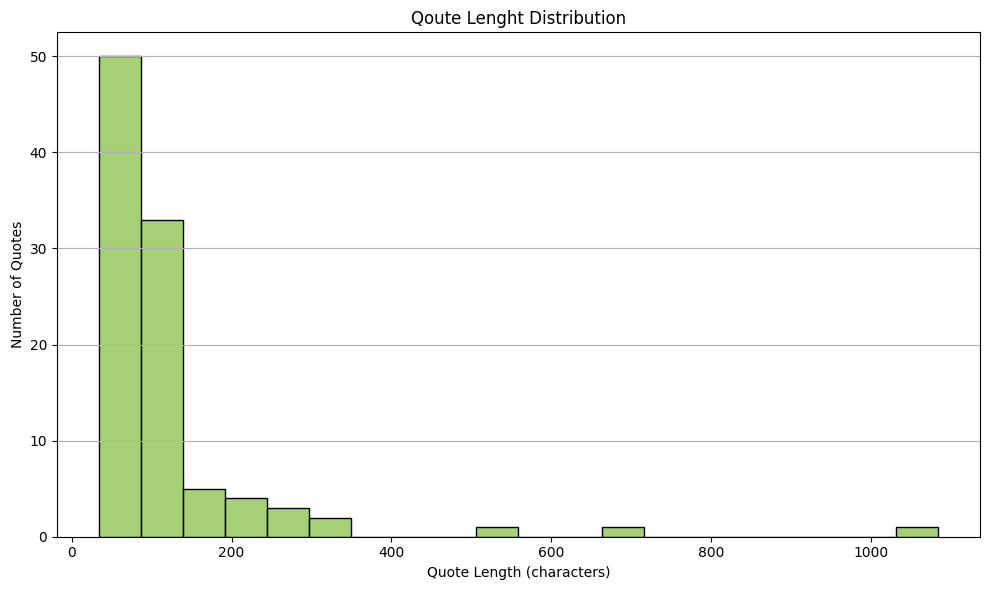

In [59]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='quote_length' , bins=20 , edgecolor='black' , color="#88C249")

plt.title('Qoute Lenght Distribution')
plt.xlabel('Quote Length (characters)')
plt.ylabel('Number of Quotes')

plt.tight_layout()
plt.grid(axis="y")
plt.savefig(f'{filepath}/quote_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
# df.groupby('author')["quote_length"].mean()
df.groupby('author')['quote_length'].mean().sort_values(ascending=False)

author
Pablo Neruda              319.000000
Bob Marley                286.333333
J.D. Salinger             241.000000
Marilyn Monroe            240.857143
Elie Wiesel               224.000000
C.S. Lewis                184.400000
Jane Austen               171.800000
Ralph Waldo Emerson       168.500000
Charles Bukowski          161.500000
Helen Keller              153.000000
Harper Lee                148.000000
Madeleine L'Engle         139.000000
Jim Henson                134.000000
Terry Pratchett           125.000000
Garrison Keillor          123.000000
J.K. Rowling              118.444444
James Baldwin             118.000000
John Lennon               117.000000
Haruki Murakami           110.000000
Dr. Seuss                 107.666667
Jimi Hendrix              103.000000
Douglas Adams              95.000000
Albert Einstein            93.700000
Alfred Tennyson            93.000000
George R.R. Martin         91.000000
Friedrich Nietzsche        82.000000
André Gide                 82.0

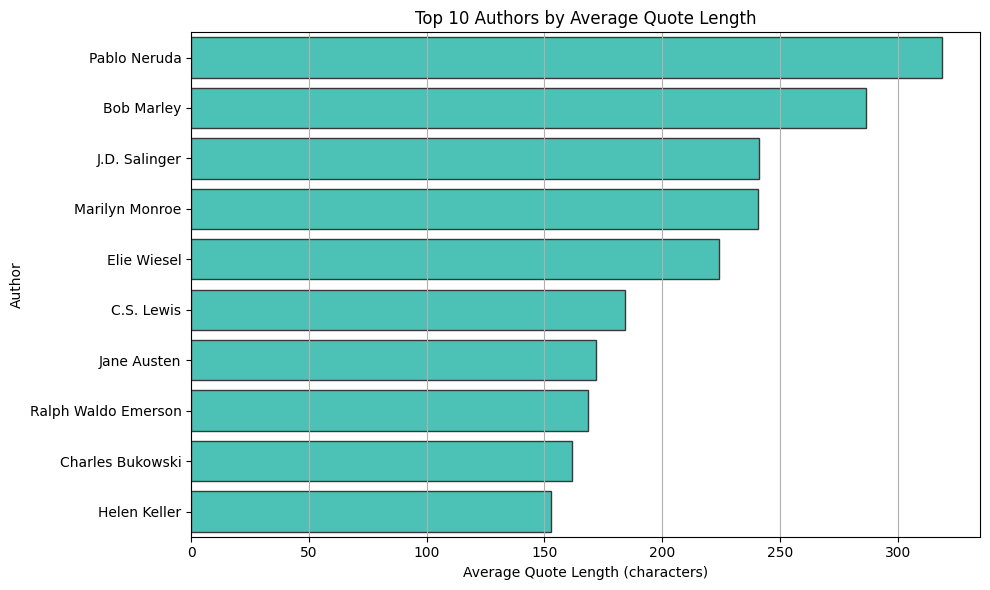

In [61]:
author_avg_length = (df.groupby('author')['quote_length'].mean()
      .sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))

sns.barplot( x=author_avg_length.values, y=author_avg_length.index ,edgecolor="#3A3939" ,color="#38D6C6")

plt.title('Top 10 Authors by Average Quote Length')
plt.xlabel('Average Quote Length (characters)')
plt.ylabel('Author')

plt.tight_layout()
plt.grid(axis="x")
plt.savefig(f'{filepath}/top_authors_average_quote_length.png',dpi=300, bbox_inches='tight')
plt.show()

In [62]:
df['tag_count'] = df['tags'].apply(len)

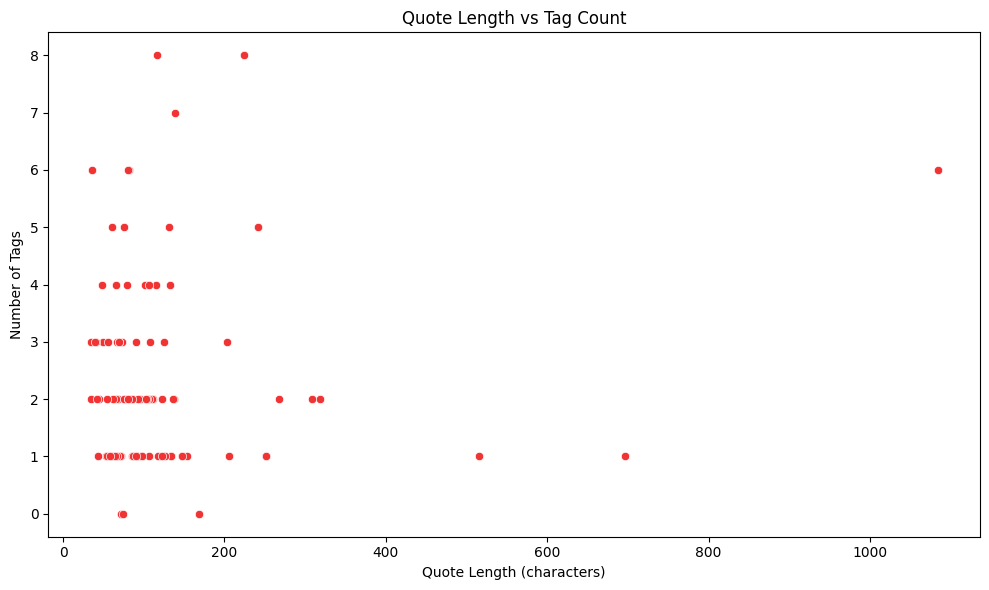

In [63]:
df['tag_count'] = df['tags'].apply(len)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='quote_length',y='tag_count' ,color="#F13333")

plt.title('Quote Length vs Tag Count')
plt.xlabel('Quote Length (characters)')
plt.ylabel('Number of Tags')

plt.tight_layout()
plt.savefig(f'{filepath}/quote_length_vs_tag_count.png', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
top10_tags = df['tags'].explode().value_counts().head(10)

In [65]:
top10_tags

tags
love             14
inspirational    13
life             13
humor            12
books            11
reading           7
friendship        5
friends           4
truth             4
death             3
Name: count, dtype: int64

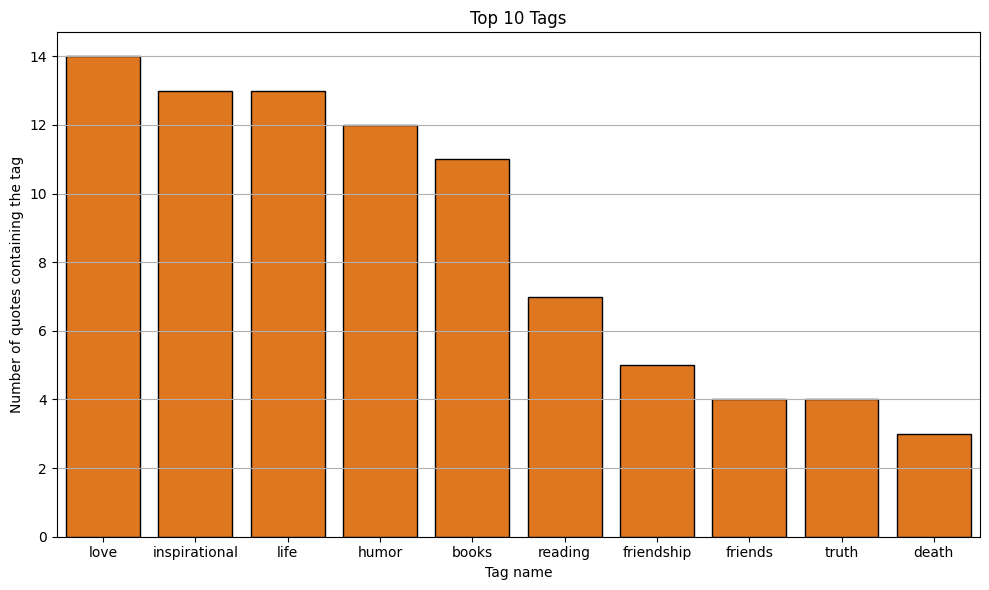

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(top10_tags ,color="#FF7300" , edgecolor='black')

plt.title('Top 10 Tags')
plt.ylabel('Number of quotes containing the tag')
plt.xlabel('Tag name')

plt.tight_layout()
plt.grid(axis="y")
plt.savefig(f'{filepath}/top10_tags.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
avg_no_tags = df.groupby('author')['tag_count'].mean().sort_values(ascending=False)

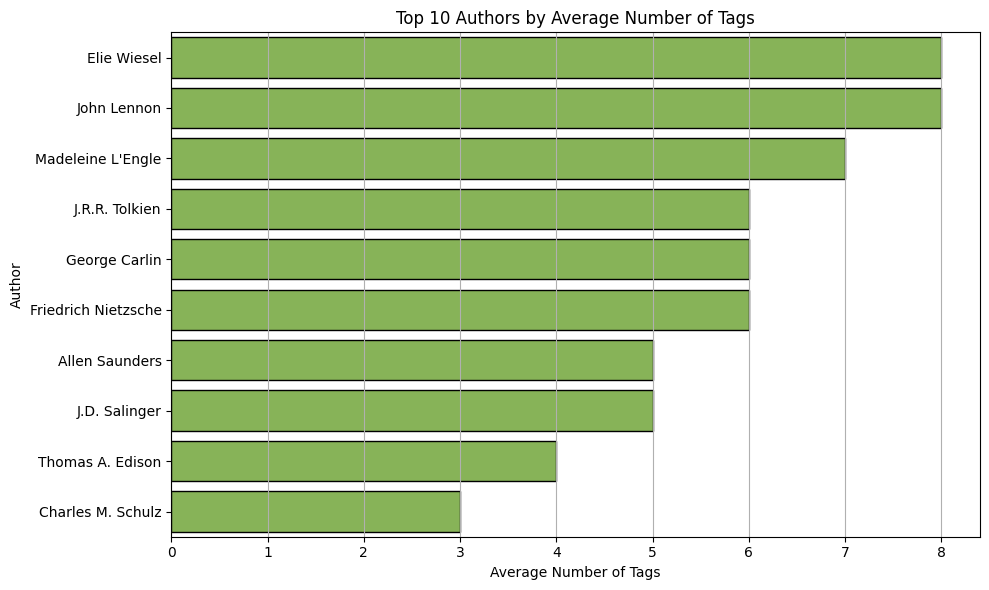

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(x=avg_no_tags.head(10).values , y=avg_no_tags.head(10).index,
            color="#88C249",edgecolor="black")

plt.title('Top 10 Authors by Average Number of Tags')
plt.xlabel('Average Number of Tags')
plt.ylabel('Author')

plt.tight_layout()
plt.grid(axis="x")

plt.savefig(f'{filepath}/top10_authors_avg_tags.png',dpi=300, bbox_inches='tight')

plt.show()

In [69]:
top_authors = df['author'].value_counts().head(10).index

In [70]:
top_authors

Index(['Albert Einstein', 'J.K. Rowling', 'Marilyn Monroe', 'Dr. Seuss',
       'Mark Twain', 'Jane Austen', 'C.S. Lewis', 'Bob Marley',
       'Mother Teresa', 'Eleanor Roosevelt'],
      dtype='object', name='author')

In [71]:
top_author_df = df[df['author'].isin(top_authors)]

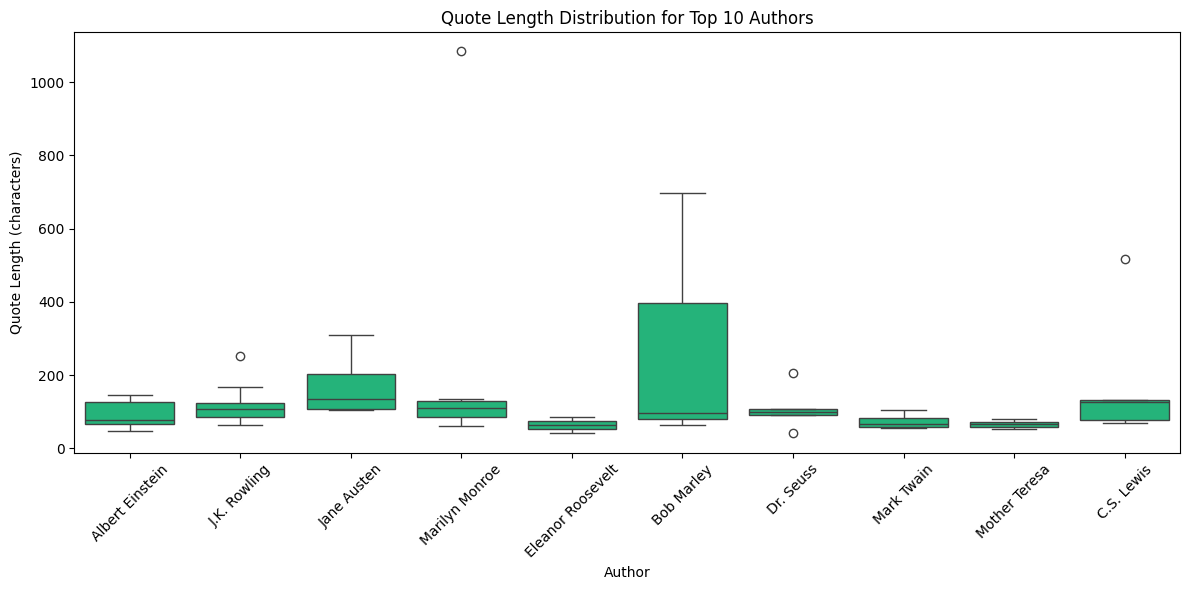

In [94]:
top_authors = df['author'].value_counts().head(10).index

top_author_df = df[df['author'].isin(top_authors)]

plt.figure(figsize=(12, 6))

sns.boxplot(data=top_author_df,
            x='author',
            y='quote_length', color="#0DCB7F")

plt.title('Quote Length Distribution for Top 10 Authors')
plt.xlabel('Author')
plt.ylabel('Quote Length (characters)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f'{filepath}/quote_length_by_top_authors.png',
    dpi=300,
    bbox_inches='tight')

plt.show()

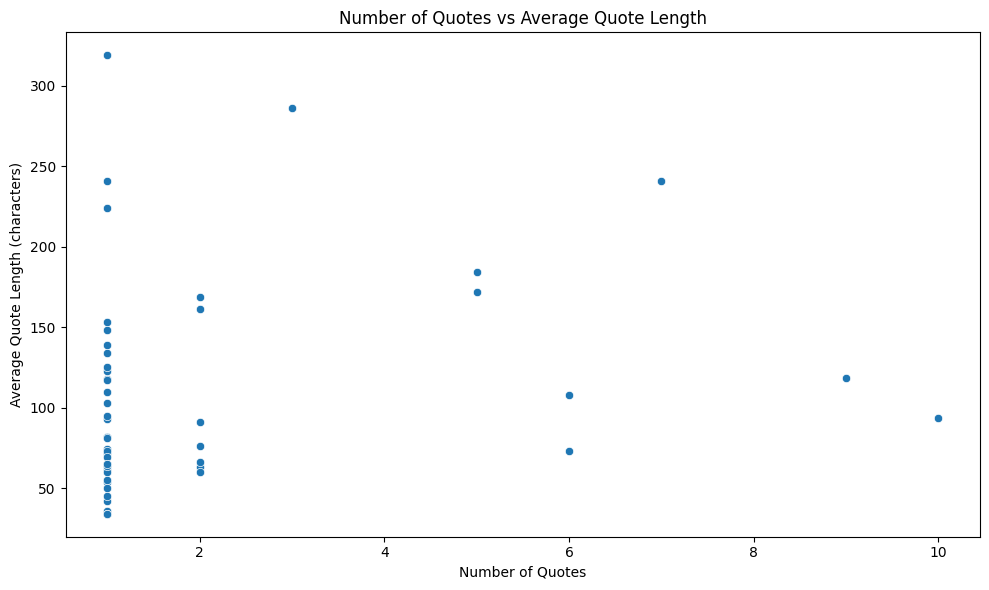

In [91]:
author_stats = (
    df.groupby('author').agg(
        quote_count=('quote', 'count'),
        avg_quote_length=('quote_length', 'mean')).reset_index()
        )

plt.figure(figsize=(10, 6))

sns.scatterplot(data=author_stats,
                 x='quote_count',
                y='avg_quote_length')

plt.title('Number of Quotes vs Average Quote Length')
plt.xlabel('Number of Quotes')
plt.ylabel('Average Quote Length (characters)')

plt.tight_layout()

plt.savefig(f'{filepath}/quote_count_vs_avg_length.png',
            dpi=300, bbox_inches='tight')

plt.show()

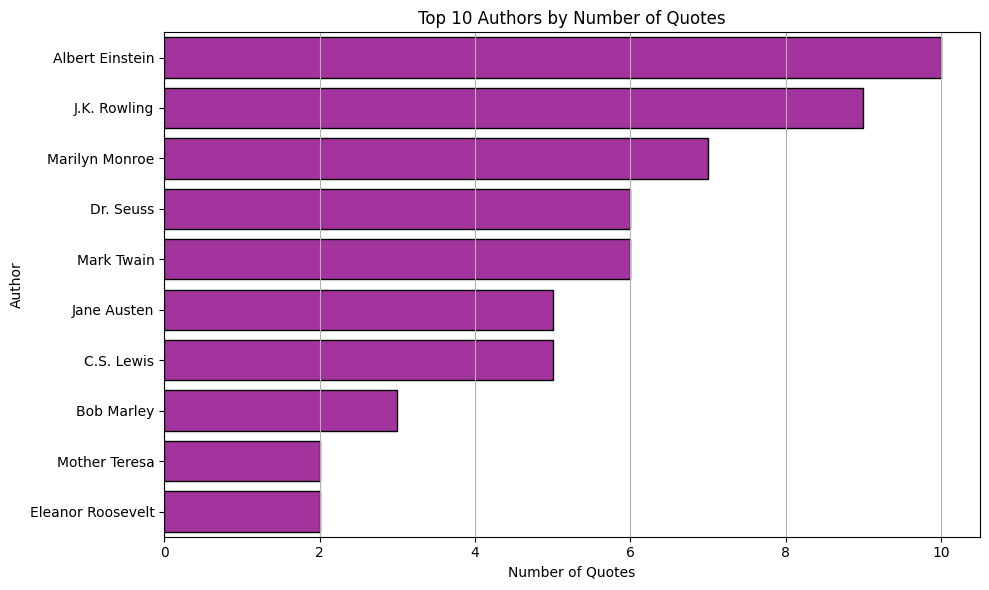

In [ ]:
top10_authors = (df['author'].value_counts().head(10))

plt.figure(figsize=(10, 6))

sns.barplot(x=top10_authors.values, y=top10_authors.index,
            edgecolor='black' , color="#B721AD")

plt.title('Top 10 Authors by Number of Quotes')
plt.xlabel('Number of Quotes')
plt.ylabel('Author')

plt.tight_layout()
plt.grid(axis="x")
plt.savefig(f'{filepath}/top10_authors_by_quote_count.png',
             dpi=300,bbox_inches='tight')
plt.show()

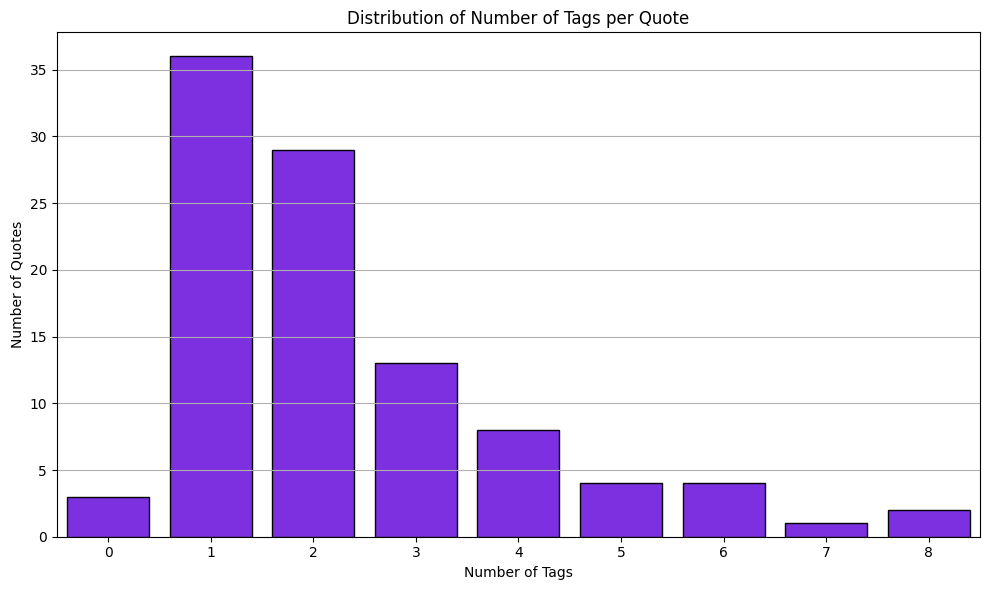

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df,x='tag_count',edgecolor='black' , color="#7913FD")

plt.title('Distribution of Number of Tags per Quote')
plt.xlabel('Number of Tags')
plt.ylabel('Number of Quotes')

plt.tight_layout()
plt.grid(axis="y")
plt.savefig( f'{filepath}/tag_count_distribution.png',dpi=300, bbox_inches='tight')

plt.show()

## 📊 EDA Insights

### 1. Top 10 Authors by Number of Quotes

* Albert Einstein has the highest number of quotes in the dataset with **10 quotes**, followed by J.K. Rowling with **9 quotes** and Marilyn Monroe with **7 quotes**.
* The number of quotes is unevenly distributed across authors, with some authors appearing much more frequently than others.
* This reflects the composition of this scraped dataset and should not be interpreted as the overall popularity of these authors.

### 2. Top 10 Tags

* **Love** is the most frequent tag with **14 occurrences**, followed by **inspirational** and **life**, each with **13 occurrences**.
* Other frequently occurring tags include **humor (12)**, **books (11)**, and **reading (7)**.
* The tag distribution shows that themes related to emotions, inspiration, life, and books are common within the collected quotes.

### 3. Distribution of Number of Tags per Quote

* Most quotes contain **one or two tags**.
* **36 quotes** have one tag and **29 quotes** have two tags.
* Only **3 quotes** have no tags, while **2 quotes** have eight tags.
* The average number of tags per quote is **2.32**, indicating that quotes generally have a small number of associated themes.

### 4. Quote Length Distribution

* Quote length ranges from **34 to 1,084 characters**.
* The median quote length is **86 characters**, while the mean is **122.27 characters**.
* Since the mean is considerably higher than the median, a small number of longer quotes increase the average.
* Most quotes are relatively short, while a smaller number of quotes are substantially longer.

### 5. Average Quote Length by Author

* Average quote length varies considerably between authors.
* Authors with longer average quotes contribute more extended text to the dataset, while others tend to have shorter quotes.
* Average length should be interpreted alongside the number of quotes per author because authors with very few quotes can have less stable averages.

### 6. Quote Length vs Tag Count

* The scatter plot shows how quote length varies with the number of assigned tags.
* The points are spread across different tag counts rather than forming a clearly defined linear pattern.
* Therefore, the dataset does not provide strong visual evidence that longer quotes consistently receive more tags.

### 7. Top 10 Authors by Average Number of Tags

* The average number of tags differs between authors.
* Some authors have quotes associated with more tags on average, while others have fewer.
* These differences describe the tagging structure of this dataset and do not necessarily indicate that one author's quotes are more thematically complex.

### 8. Quote Length Distribution for Top 10 Authors

* Quote lengths vary within individual authors rather than remaining fixed around their average.
* The boxplot highlights differences in median quote length, spread, and unusually long or short quotes between authors.
* This demonstrates why looking only at average quote length does not provide the complete picture of an author's quote-length distribution.

### 9. Number of Quotes vs Average Quote Length

* The scatter plot compares the number of quotes collected for an author with their average quote length.
* Authors with more quotes do not necessarily have longer or shorter average quotes.
* This suggests that the number of observations and average quote length represent different characteristics of the dataset.
